 The following cells are the analyses of the experiment data we gathered during *Tag der offenen Tür* on 23.01.26

In [102]:
import pandas as pd
import glob
import os
import ast
from collections import Counter
import matplotlib as plt

In [103]:
# MERGING ALL CSVS TO ONE DF
li = []
path = os.path.join("results_ai-chorales")
all_files = glob.glob(os.path.join(path, "*.csv"))
for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    li.append(df)
frame = pd.concat(li, axis=0, ignore_index=True)

Average age: 25.5


<Axes: >

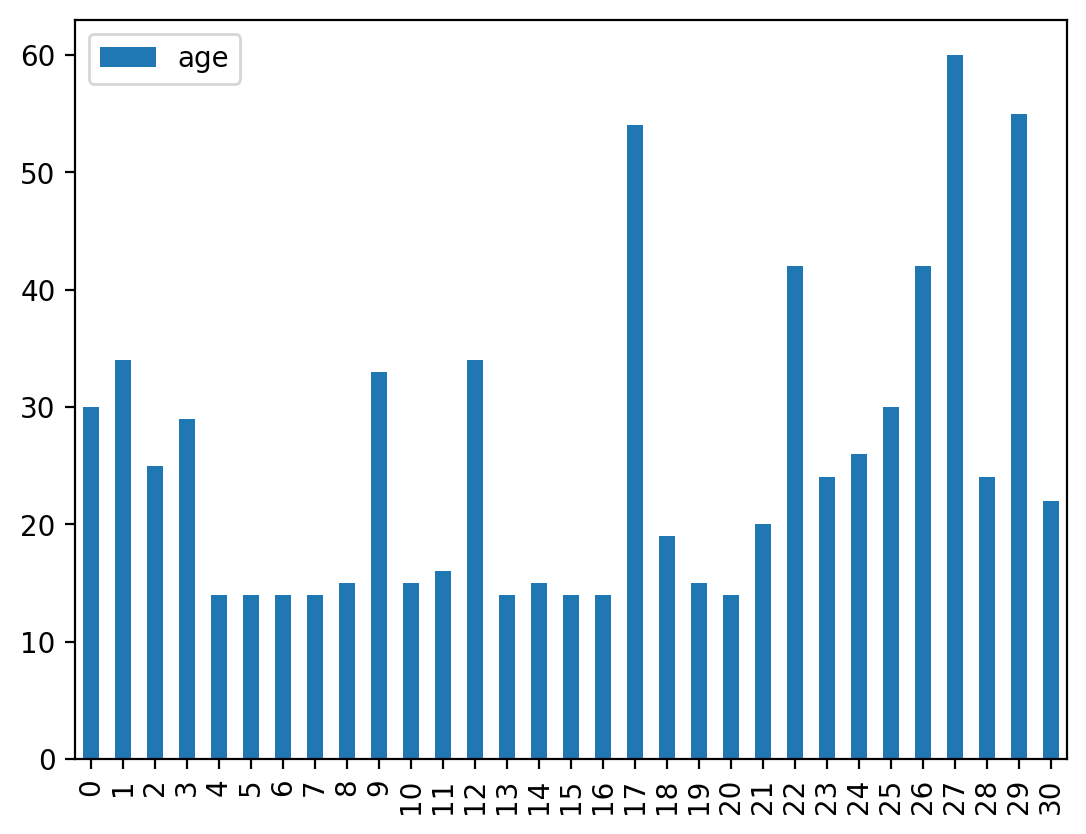

In [98]:
# ===========
# AVERAGE AGE
# ===========

age_list = []
for answers in frame["response"]:
    if isinstance(answers, str):
        try:
            parsed = ast.literal_eval(answers) 
            if isinstance(parsed, dict): # convert the strings to real dicts
                if "age" in parsed:
                    age_list.append(parsed)
        except (ValueError, SyntaxError):
            pass
df_age = pd.DataFrame(age_list)
df_age = df_age.drop([0, 1, 4, 18]) # remove unrealistic answers
df_age = df_age.reset_index(drop=True)
df_age["age"] = pd.to_numeric(df_age["age"])
print("Average age:", round(df_age["age"].mean(), 1))
df_age.plot.bar()

In [105]:
frame

,rt,response,trial_type,trial_index,plugin_version,time_elapsed,correct,training,stimulus,correct_response,timestamp
0,1536,"{""age"":""4""}",survey-text,1,2.1.0,476710,NaN,NaN,NaN,NaN,NaN
1,12171,m,audio-keyboard-response,6,2.1.0,498507,m,True,data/H/122.6-4.wav,True,NaN
2,4029,x,audio-keyboard-response,8,2.1.0,504618,x,True,data/A/output48-2.wav,True,NaN
3,5461,x,audio-keyboard-response,10,2.1.0,511851,x,False,data/A/output26-4.wav,NaN,2026-01-23T08-29-14-267Z
4,3488,m,audio-keyboard-response,11,2.1.0,516098,x,False,data/A/output14-6.wav,NaN,2026-01-23T08-29-14-267Z
...,...,...,...,...,...,...,...,...,...,...,...
835,7480,m,audio-keyboard-response,26,2.1.0,555776,m,False,data/H/290-2.wav,NaN,2026-01-23T14-28-49-967Z
836,11640,m,audio-keyboard-response,27,2.1.0,567968,m,False,data/H/292-2.wav,NaN,2026-01-23T14-28-49-967Z
837,6672,m,audio-keyboard-response,28,2.1.0,575208,m,False,data/H/283-7.wav,NaN,2026-01-23T14-28-49-967Z
838,4651,x,audio-keyboard-response,29,2.1.0,580528,x,False,data/A/output48-2.wav,NaN,2026-01-23T14-28-49-967Z
